# Solving Blackjack with Deep Q-Learning

**Blackjack** is one of the most popular casino card games that is also
infamous for being beatable under certain conditions. This version of
the game uses an infinite deck (we draw the cards with replacement), so
counting cards won’t be a viable strategy in our simulated game.

**Objective**: To win, your card sum should be greater than the
dealers without exceeding 21.

**Actions**: Agents can pick between two actions:
 - stand (0): the player takes no more cards
 - hit (1): the player will be given another card, however the player could get over 21 and bust

**Approach**: In this solution, we explore the **Deep Q-Learning** algorithm.  
**Documentation**: The full documentation used to take inspiration for this code, and the whole project is available in the Gymnasium official website.

In [ ]:
# student's matricola number

# Mattia Raffaele Ricciardelli: 1983489
# Camille Justine Gomez Eugenio: 2216495

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
from collections import defaultdict
from tqdm import tqdm

env = gym.make("Blackjack-v1", sab=True)

# Initializing the Deep Q-Network (DQNN)

In this section, we define the neural network that approximates the Q-function.

The network consists of:
- Two hidden layers with ReLU activation functions,
- A final linear layer that outputs one Q-value per action.

This model will be used by the agent to select actions and update its policy based on observed rewards.

In [ ]:
class DQNN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQNN, self).__init__()         # Initialize the QNetwork class

        # Define fully connected layers
        self.model = nn.Sequential(

            # First layer: Fully connected layer from state_dim to hidden_dim
            nn.Linear(state_dim, hidden_dim),
            # Activation function: ReLU (Rectified Linear Unit) applied after the first layer
            nn.ReLU(),
            # Second layer: Fully connected layer from hidden_dim to hidden_dim
            nn.Linear(hidden_dim, hidden_dim),
            # Activation function: ReLU applied after the second layer
            nn.ReLU(),
            # Third layer: Fully connected layer from hidden_dim to action_dim (outputs Q-values for each action)
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, x):
        # Forward pass of the network
        # Input x is processed through the sequential model to output Q-values
        return self.model(x)

# Replay Buffer

The cell below defines the `ReplayBuffer`. which:

- Stores past experiences (state, action, reward, next_state, done),
- Allows the agent to learn from **random mini-batches** of past transitions,
- Helps break correlations between consecutive experiences and improves sample efficiency.

During training, batches are sampled from the buffer and converted into PyTorch tensors for processing on the specified device (CPU or GPU).

In [ ]:
class ReplayBuffer:
    # Initialize the replay buffer with a maximum size and specify the device to store data
    def __init__(self, buffer_size, device):
        self.buffer = deque(maxlen=buffer_size)  # Create a deque to store experiences with a fixed maximum length
        self.device = device

    # Add a new experience to the replay buffer
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    # Sample a random batch of experiences from the replay buffer
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # Convert sampled states and next states into tensors and move them to the specified device
        states = torch.stack(states).to(self.device)
        next_states = torch.stack(next_states).to(self.device)

        # Convert actions into a tensor of long integers and move to the device
        actions = torch.tensor(actions, dtype=torch.long).to(self.device)

        # Convert rewards and dones into tensors of float32 and move to the device
        rewards = torch.tensor(rewards, dtype=torch.float32).to(self.device)
        dones = torch.tensor(dones, dtype=torch.float32).to(self.device)

        # Return the tensors for states, actions, rewards, next states, and dones
        return states, actions, rewards, next_states, dones

    # Return the current size of the replay buffer
    def __len__(self):
        return len(self.buffer)  # Return the number of experiences stored in the buffer

# Defining the DQN Blackjack Agent

The agent:
- Maintains a **Q-network** to estimate action values,
- Uses an **epsilon-greedy strategy** for exploration vs exploitation,
- Stores experiences in a **replay buffer** and samples mini-batches for training,
- Applies **epsilon decay** over time to reduce exploration as learning progresses,
- Trains using the **Mean Squared Error (MSE)** loss and the **Adam optimizer**.

This class encapsulates the behavior and learning strategy of the blackjack agent throughout training.

In [ ]:
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim: int,
        hidden_dim: int,
        lr: float,
        gamma: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        buffer_size: int,
        batch_size: int):

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DQNN(state_dim, action_dim, hidden_dim).to(self.device)
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr) #optimizer
        self.loss_fn = nn.MSELoss() #MSE
        self.gamma = gamma
        self.batch_size = batch_size

        # Epsilon parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.replay_buffer = ReplayBuffer(buffer_size, self.device)

    def decay_epsilon(self):
        """Linearly decay epsilon value"""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

    def get_action(self, state):
        """Epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            return random.randint(0, self.q_net.model[-1].out_features - 1)
        else:
            with torch.no_grad():
                return torch.argmax(self.q_net(state)).item()

# Training the DQN Agent

Now let's see the core training loop:

**Key steps include:**
- **Environment interaction:** At each episode, the agent collects transitions by interacting with the environment using an epsilon-greedy policy.
- **Experience storage:** Each transition `(state, action, reward, next_state, done)` is stored in the replay buffer.
- **Training:** Once the buffer has enough data, the agent samples a mini-batch to compute Q-learning targets and updates the network using backpropagation.
- **Logging:** Episode rewards, lengths, TD loss, and epsilon values are tracked for later analysis.
- **Exploration scheduling:** Epsilon decays over time, reducing randomness and encouraging exploitation of the learned policy.

This process repeats for a specified number of episodes, allowing the agent to improve its policy through trial and error.

In [ ]:
state_dim = 3
action_dim = env.action_space.n

# Hyperparameters
hidden_dim = 64
n_episodes=300000
gamma = 0.99
initial_epsilon = 1.0
epsilon_decay = initial_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.05
min_buffer_size = 5000
buffer_size = 30_000
batch_size = 128
log_interval = 10_000

# Initialization of the agent
agent = DQNAgent(state_dim,
                 action_dim,
                 hidden_dim,
                 1e-3,
                 gamma,
                 initial_epsilon,
                 epsilon_decay,
                 final_epsilon,
                 buffer_size,
                 batch_size)
device = agent.device
episode_rewards = []
player_action_by_sum = {}

In [ ]:
epsilon_values = []
episode_rewards = []
episode_lengths = []
losses = []

for ep in range(n_episodes):
    state, _ = env.reset()
    state = torch.tensor([state[0], state[1], int(state[2])], dtype=torch.float32).to(device)
    done = False
    total_reward = 0
    steps = 0  # Count steps per episode

    epsilon_values.append(agent.epsilon)  # Track epsilon

    while not done:
        action = agent.get_action(state)

        player_sum = int(state[0].item())
        if 12 <= player_sum <= 21:
            if player_sum not in player_action_by_sum:
                player_action_by_sum[player_sum] = []
            player_action_by_sum[player_sum].append(action)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = torch.tensor([next_state[0], next_state[1], int(next_state[2])], dtype=torch.float32).to(device)

        agent.replay_buffer.add(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)

    # Training (if enough in replay buffer)
    if len(agent.replay_buffer) >= min_buffer_size:
        states, actions, rewards, next_states, dones = agent.replay_buffer.sample(agent.batch_size)

        q_values = agent.q_net(states)
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        next_q_values = agent.q_net(next_states)
        max_next_q = next_q_values.max(1)[0]

        targets = rewards + agent.gamma * max_next_q * (1 - dones)

        loss = agent.loss_fn(q_value, targets.detach())
        agent.optimizer.zero_grad()
        loss.backward()
        agent.optimizer.step()

        losses.append(loss.item())  # Track loss

    # Log progress
    if (ep + 1) % log_interval == 0:
        avg_reward = np.mean(episode_rewards[-log_interval:])
        print(f"Episode {ep+1}/{n_episodes} - Avg reward: {avg_reward:.3f}, epsilon: {agent.epsilon:.3f}")

    agent.decay_epsilon()

print("Training completed!")

Episode 10000/300000 - Avg reward: -0.383, epsilon: 0.933
Episode 20000/300000 - Avg reward: -0.356, epsilon: 0.867
Episode 30000/300000 - Avg reward: -0.334, epsilon: 0.800
Episode 40000/300000 - Avg reward: -0.310, epsilon: 0.733
Episode 50000/300000 - Avg reward: -0.282, epsilon: 0.667
Episode 60000/300000 - Avg reward: -0.278, epsilon: 0.600
Episode 70000/300000 - Avg reward: -0.239, epsilon: 0.533
Episode 80000/300000 - Avg reward: -0.225, epsilon: 0.467
Episode 90000/300000 - Avg reward: -0.200, epsilon: 0.400
Episode 100000/300000 - Avg reward: -0.166, epsilon: 0.333
Episode 110000/300000 - Avg reward: -0.156, epsilon: 0.267
Episode 120000/300000 - Avg reward: -0.116, epsilon: 0.200
Episode 130000/300000 - Avg reward: -0.123, epsilon: 0.133
Episode 140000/300000 - Avg reward: -0.085, epsilon: 0.067
Episode 150000/300000 - Avg reward: -0.077, epsilon: 0.050
Episode 160000/300000 - Avg reward: -0.068, epsilon: 0.050
Episode 170000/300000 - Avg reward: -0.069, epsilon: 0.050
Episod

# Performance Visualization
The following plots provide a visual summary of the agent's learning progress during training, showing how rewards, episode lengths, and TD error evolve over time.

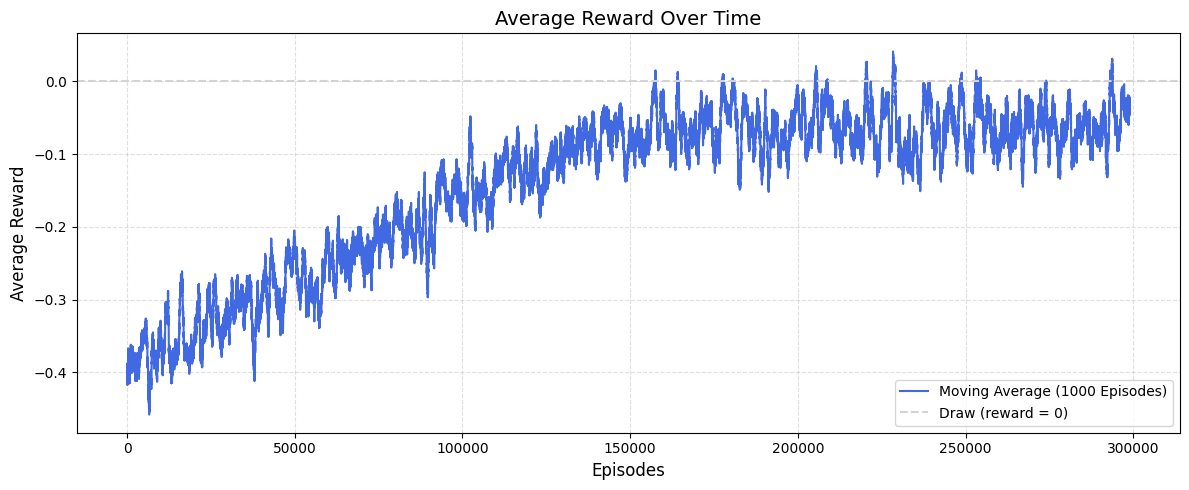

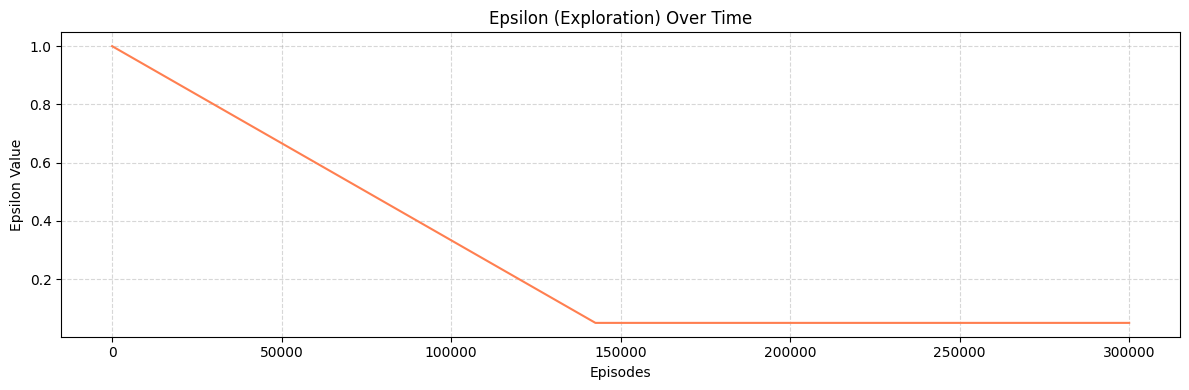

In [ ]:
#  1. Moving Average Reward
window = 1000
rolling_avg = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(range(len(rolling_avg)), rolling_avg, label=f"Moving Average ({window} Episodes)", color='royalblue')
plt.axhline(y=0, color='lightgray', linestyle='--', label='Draw (reward = 0)')
plt.title("Average Reward Over Time", fontsize=14)
plt.xlabel("Episodes", fontsize=12)
plt.ylabel("Average Reward", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" * 2)

#  2. Epsilon Over Time
plt.figure(figsize=(12, 4))
plt.plot(epsilon_values, color='coral')
plt.title("Epsilon (Exploration) Over Time")
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


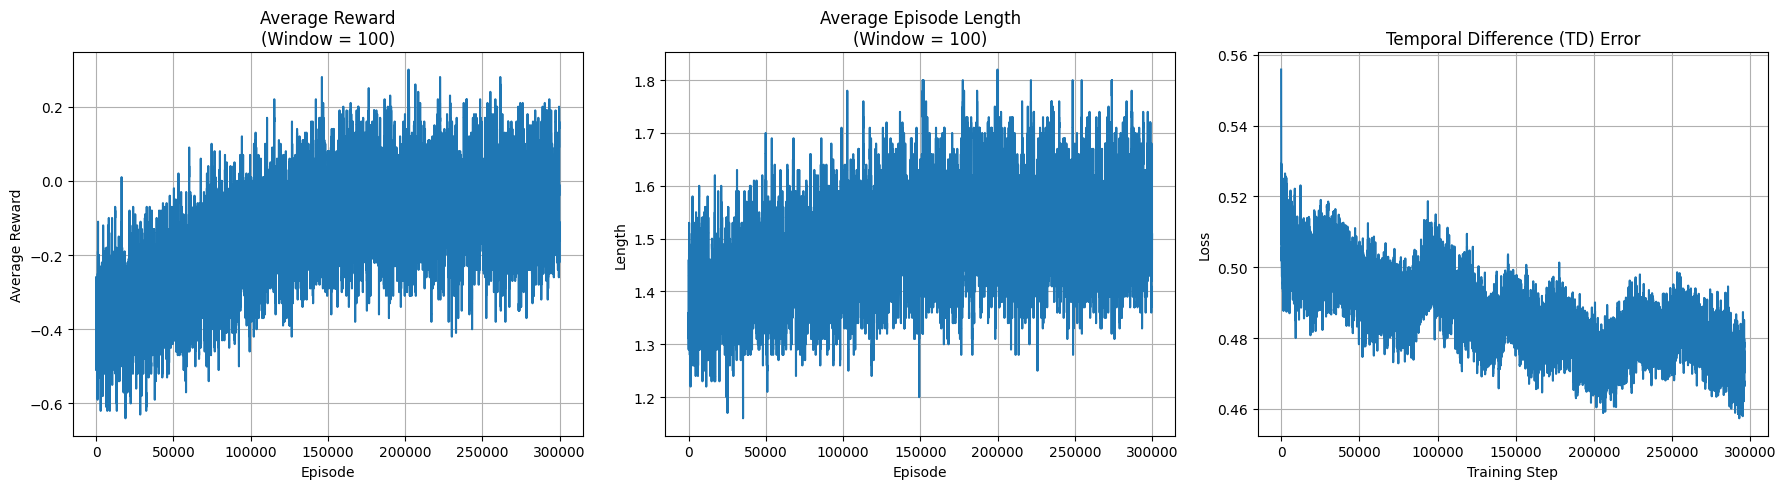

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_training_metrics_side_by_side(episode_rewards, episode_lengths, losses, window=100):
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    smoothed_lengths = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    smoothed_losses = np.convolve(losses, np.ones(window)/window, mode='valid')

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    axs[0].plot(smoothed_rewards)
    axs[0].set_title(f'Average Reward\n(Window = {window})')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Average Reward')
    axs[0].grid()

    axs[1].plot(smoothed_lengths)
    axs[1].set_title(f'Average Episode Length\n(Window = {window})')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Length')
    axs[1].grid()

    axs[2].plot(smoothed_losses)
    axs[2].set_title('Temporal Difference (TD) Error')
    axs[2].set_xlabel('Training Step')
    axs[2].set_ylabel('Loss')
    axs[2].grid()

    plt.tight_layout()
    plt.show()

plot_training_metrics_side_by_side(episode_rewards, episode_lengths, losses, window=100)

# Policy Visualization

The plots show the learned policy of the agent as heatmaps, showing whether it chooses to **Hit (H)** or **Stick (S)** in different game situations.

Two policies are shown:
- **Usable Ace:** When the player has a usable ace (counts as 11).
- **Non-Usable Ace:** When the player has no usable ace.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_policies(model):
    device = next(model.parameters()).device

    def get_policy_matrix(usable_ace):
        matrix = np.zeros((10, 10), dtype=int)
        for i, player_sum in enumerate(range(12, 22)):
            for j, dealer_card in enumerate(range(1, 11)):
                state = torch.tensor([player_sum, dealer_card, int(usable_ace)],
                                     dtype=torch.float32).to(device).unsqueeze(0)
                with torch.no_grad():
                    q_values = model(state)
                    best_action = torch.argmax(q_values).item()
                    matrix[i, j] = best_action
        return matrix

    policy_usable = get_policy_matrix(usable_ace=True)
    policy_nonusable = get_policy_matrix(usable_ace=False)

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    cmap = sns.color_palette(["#d73027", "#1a9850"])  # red = stick, green = hit

    for idx, (matrix, title) in enumerate(zip([policy_usable, policy_nonusable],
                                              ["Usable Ace", "Non-Usable Ace"])):
        ax = axs[idx]
        sns.heatmap(matrix, annot=True, fmt='d', cbar=False,
                    xticklabels=range(1, 11),
                    yticklabels=range(12, 22),
                    cmap=cmap, linewidths=0.5, linecolor='gray',
                    ax=ax)

        ax.set_title(f"Learned Policy ({title})", fontsize=14, pad=12)
        ax.set_xlabel("Dealer's Visible Card", fontsize=12)
        ax.set_ylabel("Player's Sum", fontsize=12)

        for text in ax.texts:
            val = int(text.get_text())
            text.set_text("H" if val == 1 else "S")
            text.set_color("white")
            text.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

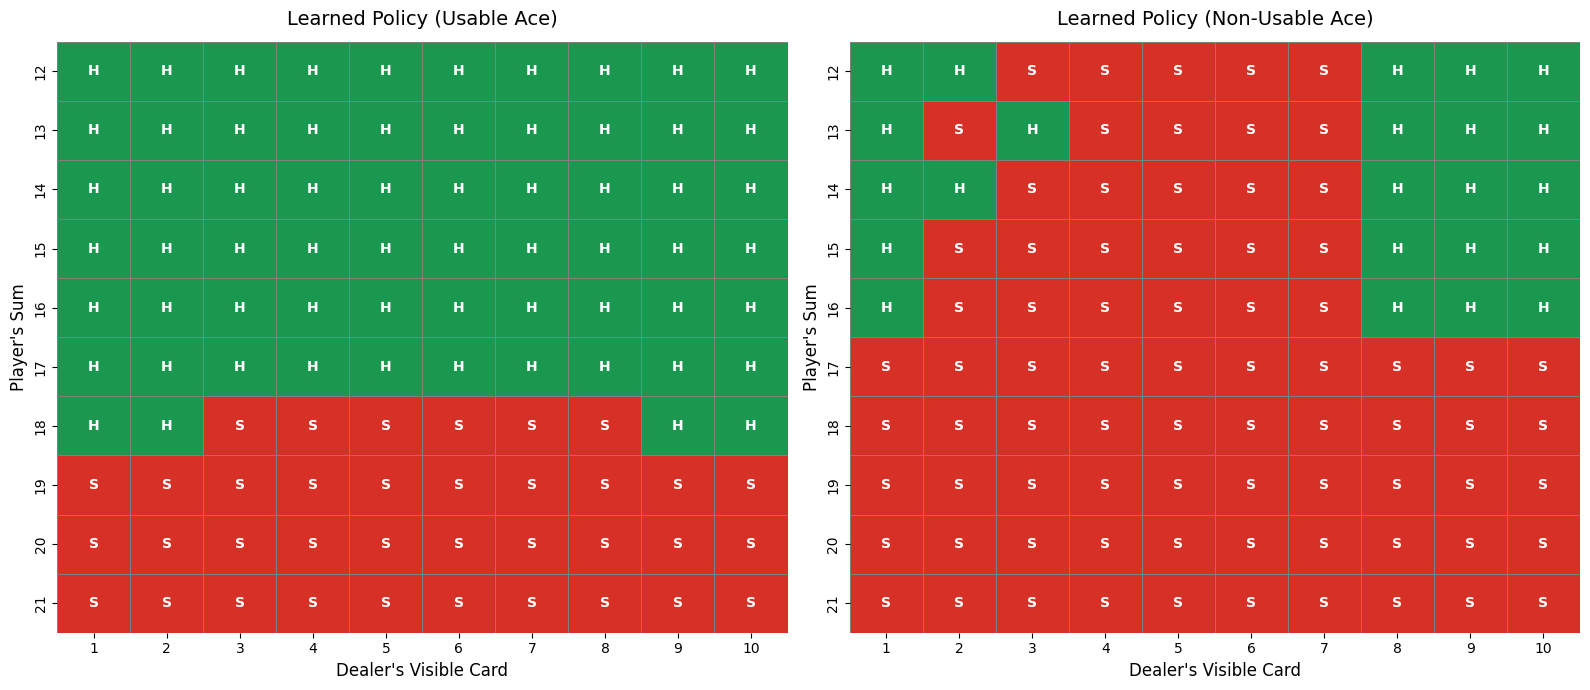

In [ ]:
plot_policies(agent.q_net)

# Test and Result
This evaluation provides insight into how well the agent has learned to play the game.

Wins: 4239, Draws: 777, Losses: 4984
=== TEST RESULTS OF GREEDY POLICY ===
Wins       : 4239 (42.39%)
Draws      : 777 (7.77%)
Losses     : 4984 (49.84%)
Average Reward: -0.0001
Consistency: 0.9510


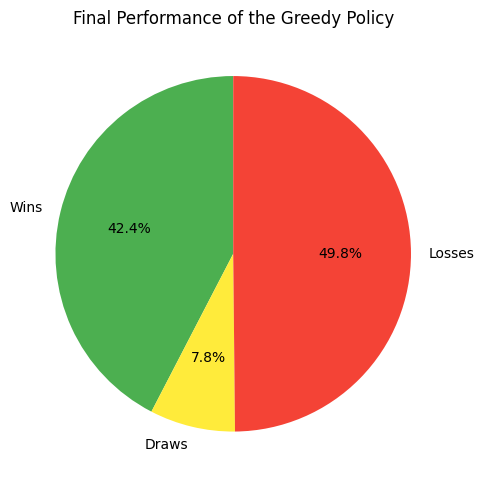

In [ ]:
def preprocess_state(state):
    """Convert the state into float32 tensor on the correct device."""
    return torch.tensor([state[0], state[1], int(state[2])], dtype=torch.float32).to(agent.device)

agent.q_net.eval()  # Set the network to evaluation mode

test_episodes = 10000
wins = 0
draws = 0
losses = 0

with torch.no_grad():
    for _ in range(test_episodes):
        state, _ = env.reset()
        state = preprocess_state(state)
        done = False
        total_reward = 0  # Reset total reward for each episode

        while not done:
            action = agent.get_action(state)  # Use greedy policy without epsilon
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            state = preprocess_state(next_state)

            total_reward += reward  # Accumulate reward for the episode

        # Count the results based on the total reward
        if total_reward > 0:  # Assuming positive reward indicates a win
            wins += 1
        elif total_reward == 0:  # Assuming zero reward indicates a draw
            draws += 1
        else:  # Assuming negative reward indicates a loss
            losses += 1

# Print evaluation results
print(f"Wins: {wins}, Draws: {draws}, Losses: {losses}")


# Results
win_rate = wins / test_episodes
average_reward = total_reward / test_episodes
consistency = np.std(episode_rewards)  # Standard deviation of rewards

print("=== TEST RESULTS OF GREEDY POLICY ===")
print(f"Wins       : {wins} ({wins / test_episodes * 100:.2f}%)")
print(f"Draws      : {draws} ({draws / test_episodes * 100:.2f}%)")
print(f"Losses     : {losses} ({losses / test_episodes * 100:.2f}%)")
print(f"Average Reward: {total_reward / test_episodes:.4f}")
print(f"Consistency: {consistency:.4f}")


labels = ['Wins', 'Draws', 'Losses']
sizes = [wins, draws, losses]
colors = ['#4CAF50', '#FFEB3B','#F44336']

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Final Performance of the Greedy Policy")
plt.tight_layout()
plt.show()

# Extension of the training
We follow up the training by exploring the performance of the agent using a two-phase epsilon greedy strategy (just like we did in the Tabular Q-Learning solution)


In [ ]:
class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim: int,
        hidden_dim: int,
        lr: float,
        gamma: float,
        epsilon_start: float,
        epsilon_min: float,
        num_episodes: int,
        buffer_size: int,
        batch_size: int):

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DQNN(state_dim, action_dim, hidden_dim).to(self.device)
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.gamma = gamma
        self.batch_size = batch_size

        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.num_episodes = num_episodes
        self.epsilon = epsilon_start  # initialize epsilon

        self.replay_buffer = ReplayBuffer(buffer_size, self.device)

    def get_epsilon(self, episode):
        decay_ratio = episode / self.num_episodes

        epsilon_split = 0.5            # intermediate epsilon value (end of first phase)
        transition_point = 0.4         # training percentage for phase transition

        if decay_ratio < transition_point:
            # Phase 1: linear decay
            epsilon = self.epsilon_start - (self.epsilon_start - epsilon_split) * (decay_ratio / transition_point)
        else:
            # Phase 2: slower exponential decay
            exponent = (decay_ratio - transition_point) * 12  # adjustable parameter
            epsilon = epsilon_split * (0.5 ** exponent)

        return max(self.epsilon_min, epsilon)

    def get_action(self, state):
        """Epsilon-greedy action selection"""
        if random.random() < self.epsilon:
            return random.randint(0, self.q_net.model[-1].out_features - 1)
        else:
            with torch.no_grad():
                return torch.argmax(self.q_net(state)).item()

In [ ]:
state_dim = 3
action_dim = env.action_space.n

# Hyperparameters
hidden_dim = 64
n_episodes = 300_000
lr = 5e-4
gamma = 0.99

epsilon_start = 1.0      # initial epsilon value (maximum exploration)
epsilon_min = 0.05       # minimum epsilon value (final exploration)
buffer_size = 30_000
batch_size = 128
log_interval = 10_000

# Initialization of the agent
agent = DQNAgent(state_dim=state_dim,
                 action_dim=action_dim,
                 hidden_dim=hidden_dim,
                 lr=lr,
                 gamma=gamma,
                 epsilon_start=epsilon_start,
                 epsilon_min=epsilon_min,
                 num_episodes=n_episodes,
                 buffer_size=buffer_size,
                 batch_size=batch_size)

device = agent.device
episode_rewards = []
player_action_by_sum = {}


In [ ]:
epsilon_values = []
episode_rewards = []
episode_lengths = []
losses = []

min_buffer_size = 5000
best_avg_reward = -float('inf')  # Track the best reward seen so far

for ep in range(n_episodes):
    state, _ = env.reset()
    state = torch.tensor([state[0], state[1], int(state[2])], dtype=torch.float32).to(device)
    done = False
    total_reward = 0
    steps = 0  # Count steps per episode

    agent.epsilon = agent.get_epsilon(ep)
    epsilon_values.append(agent.epsilon)   # Track epsilon after updating

    while not done:
        action = agent.get_action(state)

        player_sum = int(state[0].item())
        if 12 <= player_sum <= 21:
            if player_sum not in player_action_by_sum:
                player_action_by_sum[player_sum] = []
            player_action_by_sum[player_sum].append(action)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_state = torch.tensor([next_state[0], next_state[1], int(next_state[2])], dtype=torch.float32).to(device)

        agent.replay_buffer.add(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        steps += 1

    episode_rewards.append(total_reward)
    episode_lengths.append(steps)

    # Training (if enough samples in replay buffer)
    if len(agent.replay_buffer) >= min_buffer_size:
        states, actions, rewards, next_states, dones = agent.replay_buffer.sample(agent.batch_size)

        q_values = agent.q_net(states)
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        next_q_values = agent.q_net(next_states)
        max_next_q = next_q_values.max(1)[0]

        targets = rewards + agent.gamma * max_next_q * (1 - dones)

        loss = agent.loss_fn(q_value, targets.detach())
        agent.optimizer.zero_grad()
        loss.backward()
        agent.optimizer.step()

        losses.append(loss.item())  # Track loss

    # Log progress and save best model
    if (ep + 1) % log_interval == 0:
        avg_reward = np.mean(episode_rewards[-log_interval:])
        print(f"Episode {ep+1}/{n_episodes} - Avg reward: {avg_reward:.3f}, epsilon: {agent.epsilon:.3f}")

        if avg_reward > best_avg_reward:
            best_avg_reward = avg_reward
            torch.save(agent.q_net.state_dict(), 'best_model.pt')
            print(f"New best model saved (avg reward: {avg_reward:.3f})")

print("Training completed!")


Episode 10000/300000 - Avg reward: -0.385, epsilon: 0.958
New best model saved (avg reward: -0.385)
Episode 20000/300000 - Avg reward: -0.374, epsilon: 0.917
New best model saved (avg reward: -0.374)
Episode 30000/300000 - Avg reward: -0.355, epsilon: 0.875
New best model saved (avg reward: -0.355)
Episode 40000/300000 - Avg reward: -0.342, epsilon: 0.833
New best model saved (avg reward: -0.342)
Episode 50000/300000 - Avg reward: -0.347, epsilon: 0.792
Episode 60000/300000 - Avg reward: -0.316, epsilon: 0.750
New best model saved (avg reward: -0.316)
Episode 70000/300000 - Avg reward: -0.294, epsilon: 0.708
New best model saved (avg reward: -0.294)
Episode 80000/300000 - Avg reward: -0.288, epsilon: 0.667
New best model saved (avg reward: -0.288)
Episode 90000/300000 - Avg reward: -0.265, epsilon: 0.625
New best model saved (avg reward: -0.265)
Episode 100000/300000 - Avg reward: -0.256, epsilon: 0.583
New best model saved (avg reward: -0.256)
Episode 110000/300000 - Avg reward: -0.23

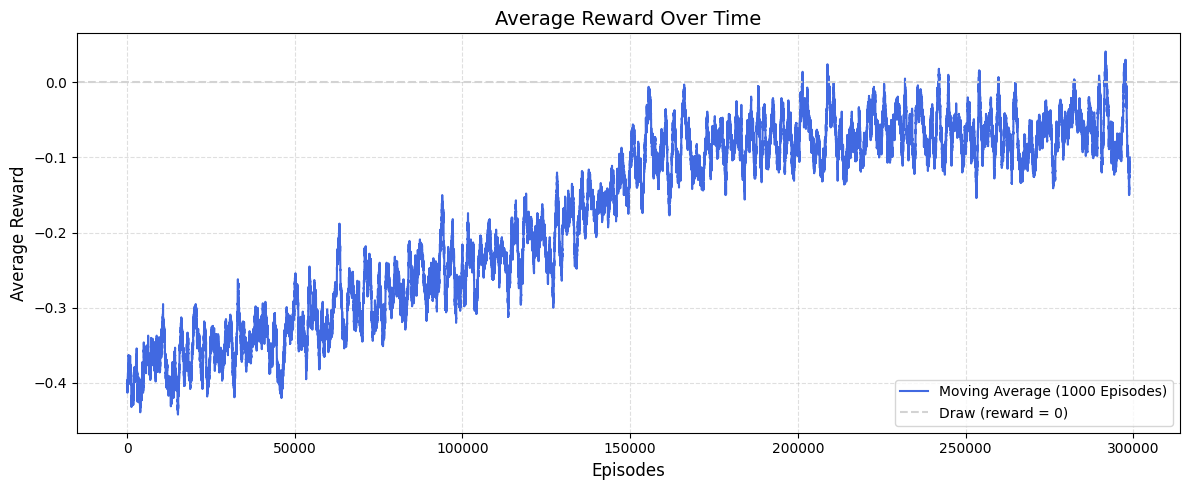

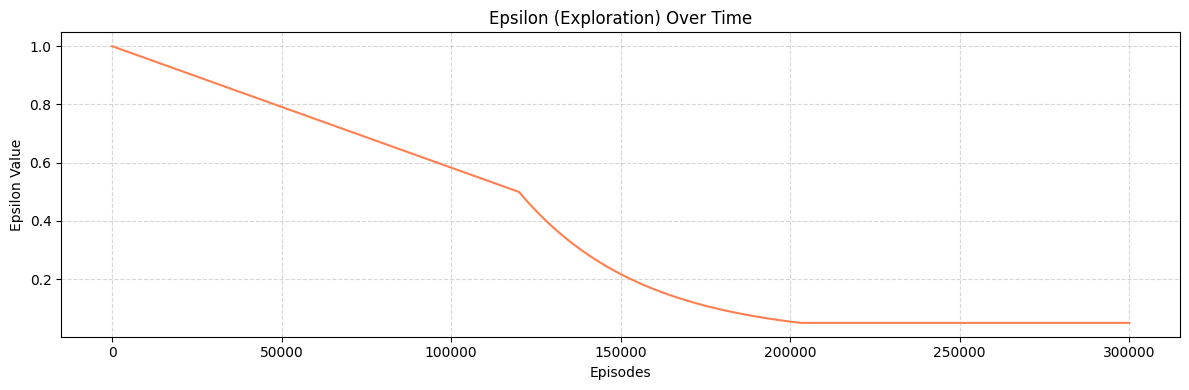

In [ ]:
#  1. Moving Average Reward
window = 1000
rolling_avg = np.convolve(episode_rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(12, 5))
plt.plot(range(len(rolling_avg)), rolling_avg, label=f"Moving Average ({window} Episodes)", color='royalblue')
plt.axhline(y=0, color='lightgray', linestyle='--', label='Draw (reward = 0)')
plt.title("Average Reward Over Time", fontsize=14)
plt.xlabel("Episodes", fontsize=12)
plt.ylabel("Average Reward", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" * 2)

#  2. Epsilon Over Time
plt.figure(figsize=(12, 4))
plt.plot(epsilon_values, color='coral')
plt.title("Epsilon (Exploration) Over Time")
plt.xlabel("Episodes")
plt.ylabel("Epsilon Value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


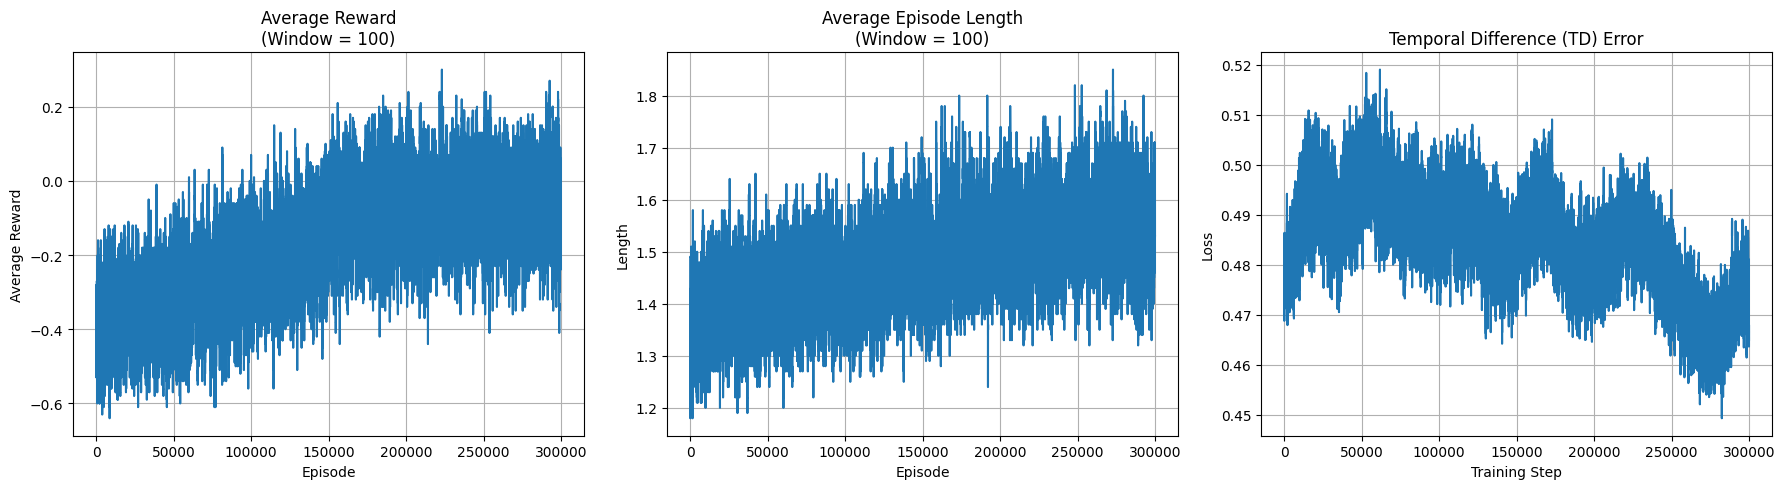

In [ ]:
def plot_training_metrics_side_by_side(episode_rewards, episode_lengths, losses, window=100):
    smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    smoothed_lengths = np.convolve(episode_lengths, np.ones(window)/window, mode='valid')
    smoothed_losses = np.convolve(losses, np.ones(window)/window, mode='valid')

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

    axs[0].plot(smoothed_rewards)
    axs[0].set_title(f'Average Reward\n(Window = {window})')
    axs[0].set_xlabel('Episode')
    axs[0].set_ylabel('Average Reward')
    axs[0].grid()

    axs[1].plot(smoothed_lengths)
    axs[1].set_title(f'Average Episode Length\n(Window = {window})')
    axs[1].set_xlabel('Episode')
    axs[1].set_ylabel('Length')
    axs[1].grid()

    axs[2].plot(smoothed_losses)
    axs[2].set_title('Temporal Difference (TD) Error')
    axs[2].set_xlabel('Training Step')
    axs[2].set_ylabel('Loss')
    axs[2].grid()

    plt.tight_layout()
    plt.show()

plot_training_metrics_side_by_side(episode_rewards, episode_lengths, losses, window=100)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def plot_policies(model):
    device = next(model.parameters()).device

    def get_policy_matrix(usable_ace):
        matrix = np.zeros((10, 10), dtype=int)
        for i, player_sum in enumerate(range(12, 22)):
            for j, dealer_card in enumerate(range(1, 11)):
                state = torch.tensor([player_sum, dealer_card, int(usable_ace)],
                                     dtype=torch.float32).to(device).unsqueeze(0)
                with torch.no_grad():
                    q_values = model(state)
                    best_action = torch.argmax(q_values).item()
                    matrix[i, j] = best_action
        return matrix

    policy_usable = get_policy_matrix(usable_ace=True)
    policy_nonusable = get_policy_matrix(usable_ace=False)

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    cmap = sns.color_palette(["#d73027", "#1a9850"])  # red = stick, green = hit

    for idx, (matrix, title) in enumerate(zip([policy_usable, policy_nonusable],
                                              ["Usable Ace", "Non-Usable Ace"])):
        ax = axs[idx]
        sns.heatmap(matrix, annot=True, fmt='d', cbar=False,
                    xticklabels=range(1, 11),
                    yticklabels=range(12, 22),
                    cmap=cmap, linewidths=0.5, linecolor='gray',
                    ax=ax)

        ax.set_title(f"Learned Policy ({title})", fontsize=14, pad=12)
        ax.set_xlabel("Dealer's Visible Card", fontsize=12)
        ax.set_ylabel("Player's Sum", fontsize=12)

        for text in ax.texts:
            val = int(text.get_text())
            text.set_text("H" if val == 1 else "S")
            text.set_color("white")
            text.set_fontweight('bold')

    plt.tight_layout()
    plt.show()

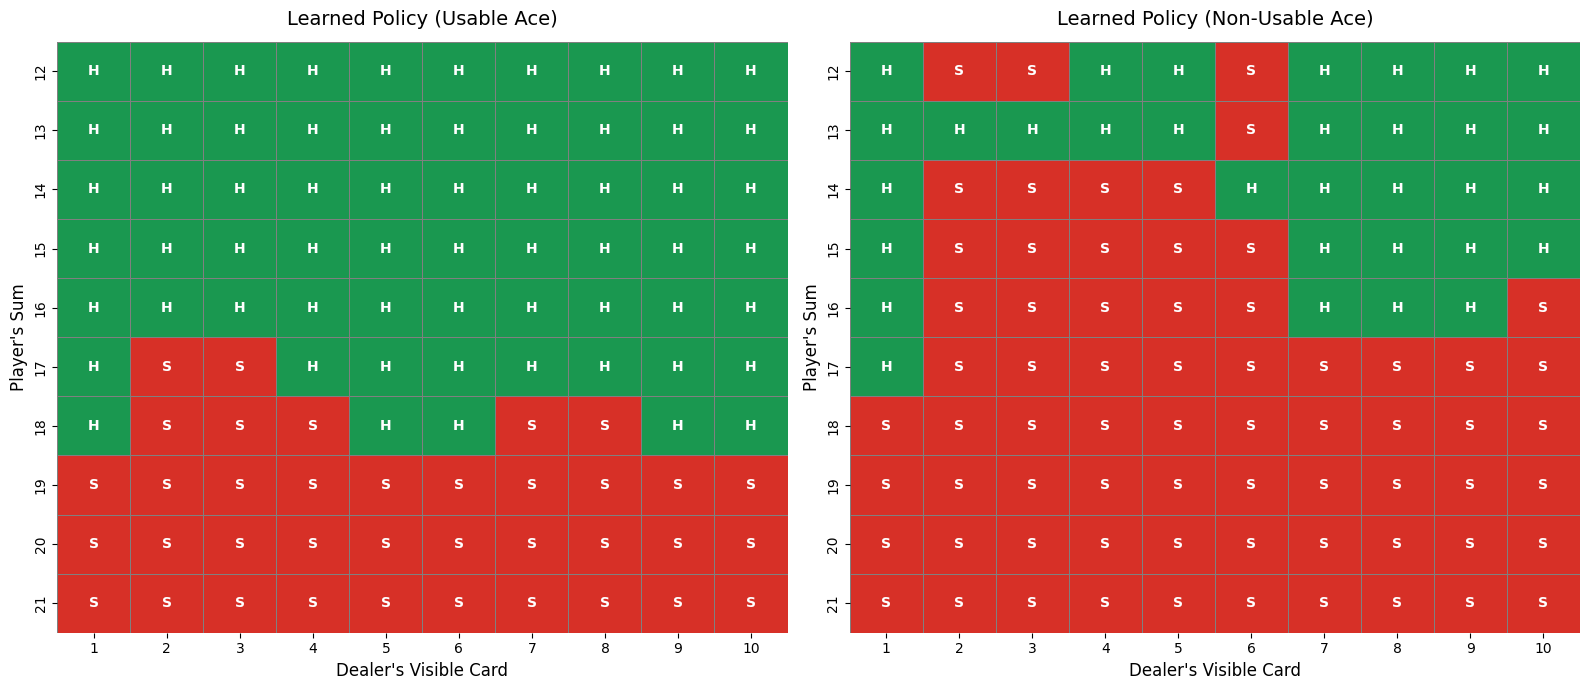

In [ ]:
plot_policies(agent.q_net)

Run 1/5 → Wins: 4216, Draws: 853, Losses: 4931, Win Rate: 42.16%
Run 2/5 → Wins: 4314, Draws: 847, Losses: 4839, Win Rate: 43.14%
Run 3/5 → Wins: 4313, Draws: 896, Losses: 4791, Win Rate: 43.13%
Run 4/5 → Wins: 4246, Draws: 863, Losses: 4891, Win Rate: 42.46%
Run 5/5 → Wins: 4323, Draws: 837, Losses: 4840, Win Rate: 43.23%

=== AVERAGED TEST RESULTS OVER MULTIPLE RUNS ===
Average Win Rate: 42.82% ± 0.43%


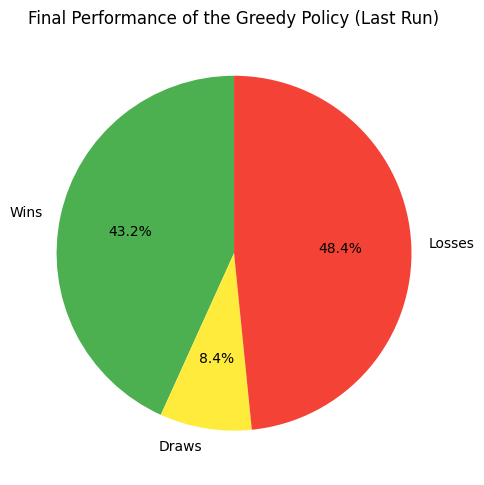

In [ ]:
def preprocess_state(state):
    """Convert the state into float32 tensor on the correct device."""
    return torch.tensor([state[0], state[1], int(state[2])], dtype=torch.float32).to(agent.device)

# Load the best saved model
agent.q_net.load_state_dict(torch.load('best_model.pt'))
agent.q_net.eval()  # Set the network to evaluation mode

n_test_runs = 5
test_episodes = 10000  # Per ogni run
win_rates = []
final_results = []  # For pie chart visualization

for run in range(n_test_runs):
    wins, draws, losses = 0, 0, 0
    total_reward = 0

    with torch.no_grad():
        for _ in range(test_episodes):
            state, _ = env.reset()
            state = preprocess_state(state)
            done = False

            while not done:
                action = torch.argmax(agent.q_net(state)).item()  # Greedy policy
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                state = preprocess_state(next_state)

                total_reward += reward
                if done:
                    if reward > 0:
                        wins += 1
                    elif reward == 0:
                        draws += 1
                    else:
                        losses += 1

    win_rate = wins / test_episodes
    win_rates.append(win_rate)
    final_results.append((wins, draws, losses))

    print(f"Run {run+1}/{n_test_runs} → Wins: {wins}, Draws: {draws}, Losses: {losses}, Win Rate: {win_rate:.2%}")

# Global statistics
mean_win_rate = np.mean(win_rates)
std_win_rate = np.std(win_rates)

print("\n=== AVERAGED TEST RESULTS OVER MULTIPLE RUNS ===")
print(f"Average Win Rate: {mean_win_rate*100:.2f}% ± {std_win_rate*100:.2f}%")

# Visualize one run (e.g., last)
last_wins, last_draws, last_losses = final_results[-1]

labels = ['Wins', 'Draws', 'Losses']
sizes = [last_wins, last_draws, last_losses]
colors = ['#4CAF50', '#FFEB3B','#F44336']

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Final Performance of the Greedy Policy (Last Run)")
plt.tight_layout()
plt.show()